In [1]:
# calculate and compare rates from different methods

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as integrate

import analysis.utils as utils # here's rate calculation functions
import analysis.plotter as plotter
import analysis.config as config

import math

In [3]:
# todo: v_E is actually a function of time: v_E = 244 + 15* np.sin(2*np.pi*y) km/s
def velo_distributions(v):
    return np.exp(-(v+config.v_E)**2/config.v_0**2)
def velo_integrant(v):
    return 4*np.pi*v**2*np.exp(-(v+config.v_E)**2/config.v_0**2)
# normalization factor
k = integrate.quad(velo_integrant, 0, config.v_esc)[0]

In [4]:
# # this is dR/dE_R
# def differential_spectrum(E_R):
#     R_0 = 540./config.A/m_D*xs*1*(config.v_0/230) 
#     E_0 = 1/2*m_D*(config.v_0)**2
#     m_T = config.A*0.938 
#     r = 4*(m_D*m_T)/(m_D+m_T)**2
#     def integrant(v):
#         return 1/v * velo_distributions(v) * 4* np.pi * v**2
#     # v_min = np.sqrt(2*E_R/r/m_D)-config.v_E
#     v_min = np.sqrt(E_R/r/E_0)*config.v_0
#     v_max = config.v_esc
#     print(r,v_min, v_max, config.v_esc)
#     # print("int", integrate.quad(integrant, v_min, v_max)[0])
#     # print("diff_sepc", R_0/E_0/r/(2*np.pi*config.v_0**2) * integrate.quad(integrant, v_min, v_max)[0])
#     return R_0/E_0/r/(2*np.pi*config.v_0**2) * integrate.quad(integrant, v_min, v_max)[0]
    
# def differential_spectrum_after_corrections(E_R):
#     # nuclear form factor
#     F = np.exp(-1/3*(6.92*10**-3)**2*config.A*((1.14*config.A)**1/3)**2)
#     return differential_spectrum(E_R) * config.A**2 * F

# def get_spectrum_from_numerical():

#     return differential_spectrum_after_corrections

# #this cell didn't give correct result...

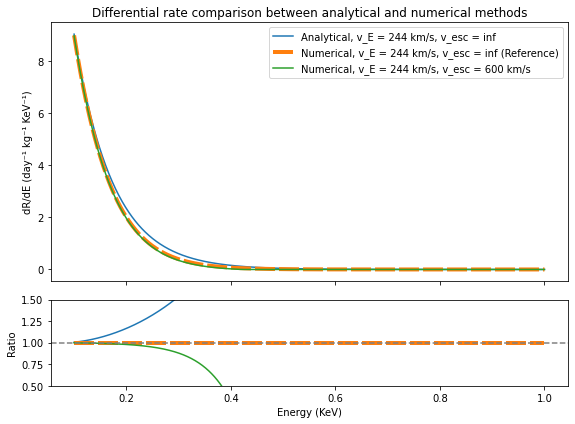

In [ ]:
# function test, compare with the next cell
# Generate energy range in GeV and convert to KeV
E_Rs_GeV = np.linspace(0.1*1e-6, 1e-6 * 1, 1000)

# Compute differential rates and normalize
# divide by A^2 because don't consider interaction factor here, 
# that is, xs = xs per nucleus (only to compare with previous results)
dRs0 = [utils.get_spectrum_in_GeV_analytical(E)/config.A**2 for E in E_Rs_GeV]
dRs1 = [utils.get_spectrum_in_GeV_numerical(E)/config.A**2 for E in E_Rs_GeV]
# v.esc= inf.
config.update_constants(v_esc=999999.)
dRs2 = [utils.get_spectrum_in_GeV_numerical(E)/config.A**2 for E in E_Rs_GeV]
config.reset_constants()

plotter.plot_differential_rate_with_ratio(
    E_Rs_GeV,
    [dRs0, dRs2, dRs1],
    labels=[
        "Analytical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = 600 km/s"
    ],
    reference_index=1,
    unit_conversion=True,
    title="Differential rate comparison between analytical and numerical methods",
)

In [6]:
# keep this cell for comparison or sanity check of refactored function
# # Define conversion factor
# GeV_to_KeV = 1e6  # 1 GeV = 10^6 KeV

# # Generate energy range in GeV and convert to KeV
# E_Rs_GeV = np.linspace(0.1e-6, 0.1e-6 * 5, 1000)
# E_Rs_KeV = E_Rs_GeV * GeV_to_KeV

# # Compute differential rates and normalize
# dRs0 = [get_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# dRs1 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]

# # v.esc= inf.
# config.update_constants(v_esc=999999.)
# dRs2 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# config.reset_constants()

# # Update for v_E = 200 km/s
# config.update_constants(v_E=200.0)
# dRs3 = [differential_spectrum(E) / config.A**2 for E in E_Rs_GeV]
# config.reset_constants()

# # Convert dR/dE to KeV-1
# dRs0_KeV = np.array(dRs0) / GeV_to_KeV
# dRs1_KeV = np.array(dRs1) / GeV_to_KeV
# dRs2_KeV = np.array(dRs2) / GeV_to_KeV
# dRs3_KeV = np.array(dRs3) / GeV_to_KeV

# # Compute ratios relative to dRs1_KeV (numerical, v_E = 244 km/s, v_esc = 600 km/s)
# ratio_0 = np.divide(dRs0_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_1 = np.divide(dRs1_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_2 = np.divide(dRs2_KeV, dRs1_KeV, where=dRs1_KeV != 0)
# ratio_3 = np.divide(dRs3_KeV, dRs1_KeV, where=dRs1_KeV != 0)



# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1.5]})

# # --- Main panel ---
# ax[0].plot(E_Rs_KeV, dRs0_KeV, label="analytical, v_E = 244 km/s, v_esc = inf")
# ax[0].plot(E_Rs_KeV, dRs1_KeV, label="numerical, v_E = 244 km/s, v_esc = 600 km/s")
# ax[0].plot(E_Rs_KeV, dRs2_KeV, label="numerical, v_E = 244 km/s, v_esc = inf")
# ax[0].plot(E_Rs_KeV, dRs3_KeV, label="numerical, v_E = 200 km/s, v_esc = 600 km/s")

# ax[0].set_ylabel("dR/dE (day⁻¹ kg⁻¹ KeV⁻¹)")
# ax[0].set_title("Differential Rate")
# ax[0].legend()

# # --- Ratio panel ---
# ax[1].plot(E_Rs_KeV, ratio_0, label="analytical / numerical")
# ax[1].plot(E_Rs_KeV, ratio_1)
# ax[1].plot(E_Rs_KeV, ratio_2, label="numerical (v_esc = inf) / numerical")
# ax[1].plot(E_Rs_KeV, ratio_3, label="numerical (v_E = 200) / numerical")

# ax[1].set_xlabel("Energy (KeV)")
# ax[1].set_ylabel("Ratio to numerical (244, 600)")
# ax[1].set_ylim(0.5,1.5)
# ax[1].legend()



# # Show the plot
# plt.tight_layout()
# plt.show()



In [7]:
# normalize as in paper
m_D = config.m_D_0
xs = config.xs_0
E0 = 1/2 * m_D * (config.v_0/(3*10**5))**2 # in GeV # 2.93e-07
m_T = config.A*0.938
r = 4*m_D*m_T/(m_D+m_T)**2 # 0.1413
R_0 = 540/(config.A*m_D)*(xs)*1*(config.v_0/230) #1.9285

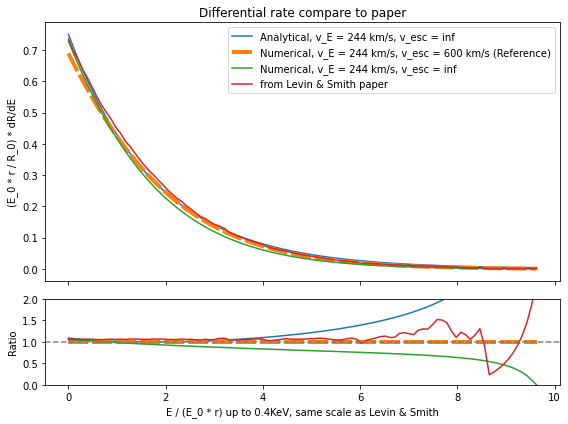

In [9]:
E_Rs = np.linspace(0, 0.4*1e-6 , 100)
dRs0 = np.vectorize(utils.get_spectrum_in_GeV_analytical)(E_Rs)
dRs1 = np.vectorize(utils.get_spectrum_in_GeV_numerical)(E_Rs)
config.update_constants(v_E=219.0)
dRs2 = np.vectorize(utils.get_spectrum_in_GeV_numerical)(E_Rs)
config.reset_constants()
# normalize energy
E_scaled = E_Rs / (E0 * r)
# Normalize rate by (E0 * r / R_0) / A^2 
# in paper the interaction factor ~A^2 is not included yet
norm_factor = (E0 * r / R_0) / config.A**2
dRs0_norm, dRs1_norm, dRs2_norm = [dRs * norm_factor for dRs in (dRs0, dRs1, dRs2)]
# line from the paper
line_from_paper = np.loadtxt("Levin_fig2.csv", delimiter=",") 
x_paper, y_paper = line_from_paper[:,0], line_from_paper[:,1]
# Interpolate the digitized y-values to match E_Rs
x_paper, y_paper = line_from_paper[:,0], line_from_paper[:,1]
interpolation_function = interp1d(x_paper, y_paper, kind='linear', bounds_error=False, fill_value="extrapolate")
y_interpolated = interpolation_function(E_scaled)

plotter.plot_differential_rate_with_ratio(
    E_scaled,
    [dRs0_norm, dRs1_norm, dRs2_norm, y_interpolated],
    labels=[
        "Analytical, v_E = 244 km/s, v_esc = inf",
        "Numerical, v_E = 244 km/s, v_esc = 600 km/s",
        "Numerical, v_E = 244 km/s, v_esc = inf",
        "from Levin & Smith paper"
    ],
    reference_index=1,
    title="Differential rate compare to paper",
    ratio_rage=(0, 2),
    unit_conversion=False,
    xlabel="E / (E_0 * r) up to 0.4KeV, same scale as Levin & Smith",
    ylabel="(E_0 * r / R_0) * dR/dE"
)

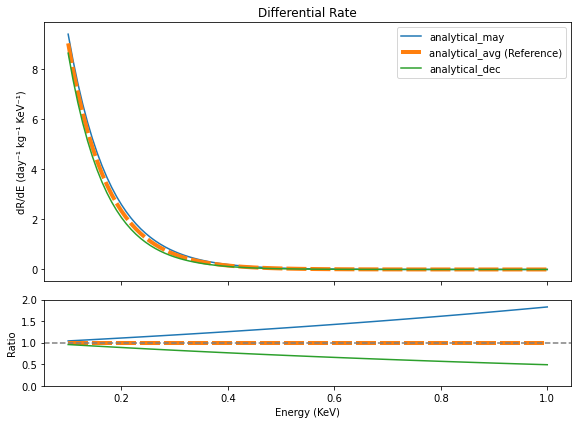

In [14]:
E_Rs_GeV = np.linspace(0.1*1e-6, 1e-6, 100)

# Compute differential rates
config.reset_constants()
# dRs00 = R_0 / E0 / r * np.exp(-E_Rs_GeV / E0 / r)
dRs0 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.update_constants(c1=0.734, c2=0.535)
dRs1 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.update_constants(c1=0.774, c2=0.592)
dRs2 = np.array([utils.get_spectrum_in_GeV_analytical(E) for E in E_Rs_GeV]) / config.A**2
config.reset_constants()  # Ensure default state


plotter.plot_differential_rate_with_ratio(
    E_Rs_GeV,
    [dRs1, dRs0, dRs2],  
    labels=[
        "analytical_may",
        "analytical_avg",
        "analytical_dec"
    ],
    ratio_rage=(0, 2),
)